In [1]:
cd ..

/Users/julenlegido/Downloads/SpikingNeuralNetworks


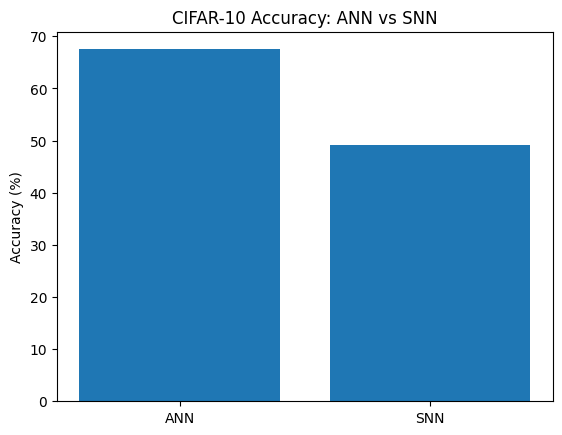

In [2]:
from matplotlib import pyplot as plt
import json

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

labels = ["ANN", "SNN"]
accuracy = [67.5, 49.1]

plt.bar(labels, accuracy)
plt.title("CIFAR-10 Accuracy: ANN vs SNN")
plt.ylabel("Accuracy (%)")
plt.show()

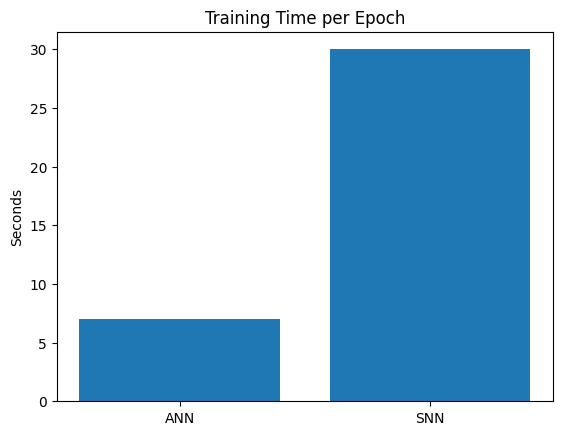

In [8]:
time = [7, 30]

plt.bar(labels, time)
plt.title("Training Time per Epoch")
plt.ylabel("Seconds")
plt.show()

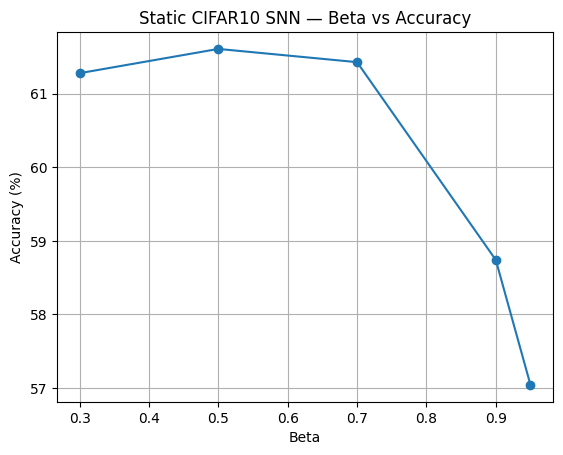

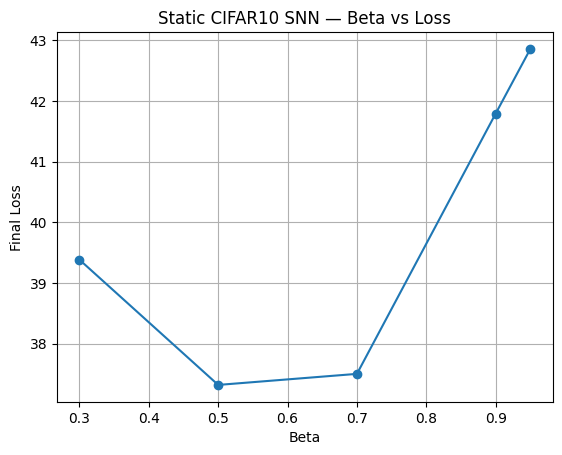

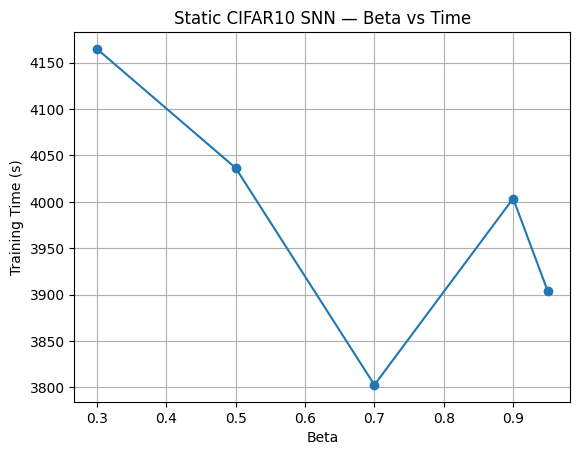

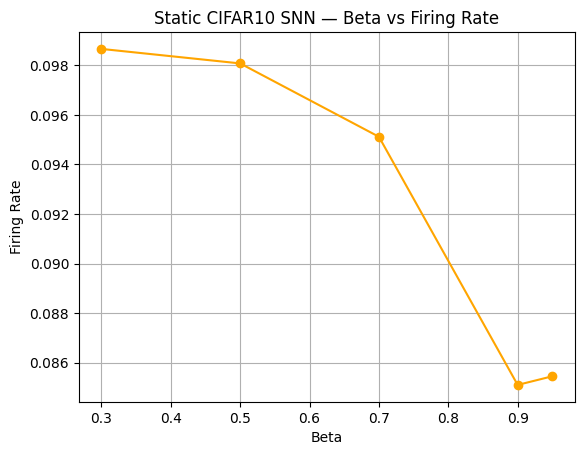

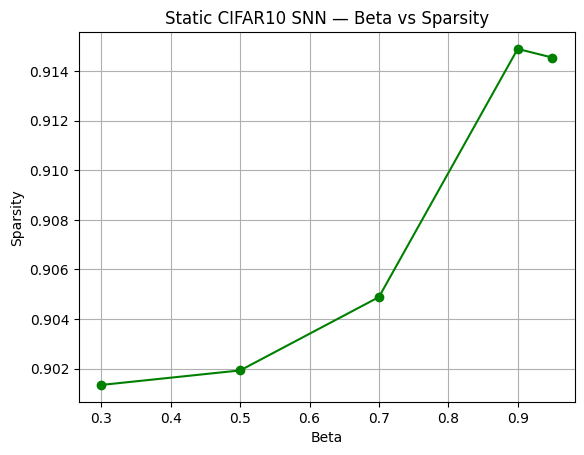

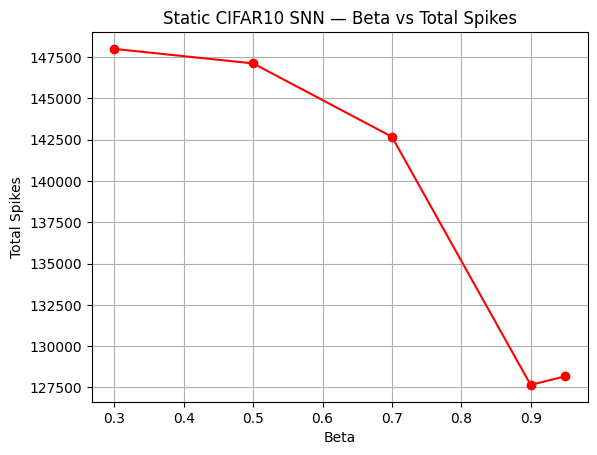

In [11]:
#beta comparison

beta03 = load_json("results/logs/snn_MSEKaimingImproved_beta0.3_T15.json")
beta05 = load_json("results/logs/snn_MSEKaimingImproved_beta0.5_T15.json")
beta07 = load_json("results/logs/snn_MSEKaimingImproved_beta0.7_T15.json")
beta09 = load_json("results/logs/snn_MSEKaimingImproved_beta0.9_T15.json")
beta095 = load_json("results/logs/snn_MSEKaimingImproved_beta0.95_T15.json")

sbeta03 = load_json("results/logs/spike_analysis_beta0.3_T15.json")
sbeta05 = load_json("results/logs/spike_analysis_beta0.5_T15.json")
sbeta07 = load_json("results/logs/spike_analysis_beta0.7_T15.json")
sbeta09 = load_json("results/logs/spike_analysis_beta0.9_T15.json")
sbeta095 = load_json("results/logs/spike_analysis_beta0.95_T15.json")

betas = [
    beta03["beta"],
    beta05["beta"],
    beta07["beta"],
    beta09["beta"],
    beta095["beta"]
]

accuracies = [
    beta03["accuracy"] [-1],
    beta05["accuracy"][-1],
    beta07["accuracy"][-1],
    beta09["accuracy"][-1],
    beta095["accuracy"][-1]
]

losses = [
    beta03["loss"][-1],
    beta05["loss"][-1],
    beta07["loss"][-1],
    beta09["loss"][-1],
    beta095["loss"][-1]
]

times = [
    sum(beta03["time"]),
    sum(beta05["time"]),
    sum(beta07["time"]),
    sum(beta09["time"]),
    sum(beta095["time"])
]

firing_rates = [
    sbeta03["firing_rate"],
    sbeta05["firing_rate"],
    sbeta07["firing_rate"],
    sbeta09["firing_rate"],
    sbeta095["firing_rate"]
]

sparsities = [
    sbeta03["sparsity"],
    sbeta05["sparsity"],
    sbeta07["sparsity"],
    sbeta09["sparsity"],
    sbeta095["sparsity"]
]

total_spikes = [
    sbeta03["total_spikes"],
    sbeta05["total_spikes"],
    sbeta07["total_spikes"],
    sbeta09["total_spikes"],
    sbeta095["total_spikes"]
]

# Accuracy
plt.plot(betas, accuracies, marker="o")
plt.xlabel("Beta")
plt.ylabel("Accuracy (%)")
plt.title("Static CIFAR10 SNN — Beta vs Accuracy")
plt.grid()
plt.savefig("results/figures/beta_accuracy_comparison_CIFAR10.png", dpi=300)
plt.show()

# Loss
plt.plot(betas, losses, marker="o")
plt.xlabel("Beta")
plt.ylabel("Final Loss")
plt.title("Static CIFAR10 SNN — Beta vs Loss")
plt.grid()
plt.savefig("results/figures/beta_loss_comparison_CIFAR10.png", dpi=300)
plt.show()

# Time
plt.plot(betas, times, marker="o")
plt.xlabel("Beta")
plt.ylabel("Training Time (s)")
plt.title("Static CIFAR10 SNN — Beta vs Time")
plt.grid()
plt.savefig("results/figures/beta_time_comparison_CIFAR10.png", dpi=300)
plt.show()

# Firing Rate
plt.plot(betas, firing_rates, marker="o", color="orange")
plt.xlabel("Beta")
plt.ylabel("Firing Rate")
plt.title("Static CIFAR10 SNN — Beta vs Firing Rate")
plt.grid()
plt.savefig("results/figures/beta_firingRate_comparison_CIFAR10.png", dpi=300)
plt.show()

# Sparsity
plt.plot(betas, sparsities, marker="o", color="green")
plt.xlabel("Beta")
plt.ylabel("Sparsity")
plt.title("Static CIFAR10 SNN — Beta vs Sparsity")
plt.grid()
plt.savefig("results/figures/beta_sparsity_comparison_CIFAR10.png", dpi=300)
plt.show()

# Total Spikes
plt.plot(betas, total_spikes, marker="o", color="red")
plt.xlabel("Beta")
plt.ylabel("Total Spikes")
plt.title("Static CIFAR10 SNN — Beta vs Total Spikes")
plt.grid()
plt.savefig("results/figures/beta_totalSpikes_comparison_CIFAR10.png", dpi=300)
plt.show()

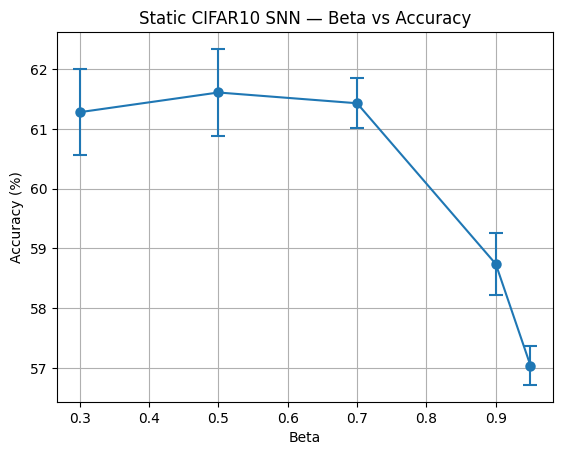

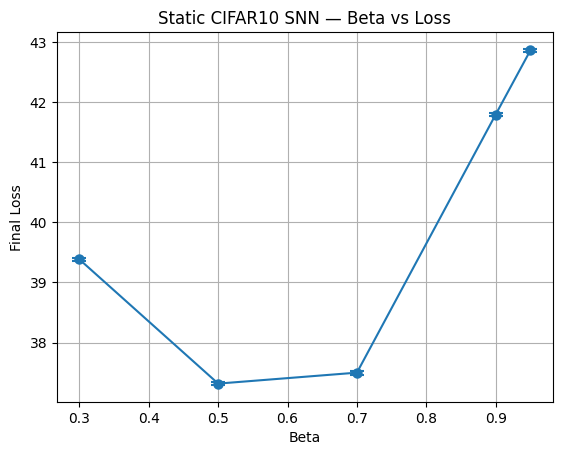

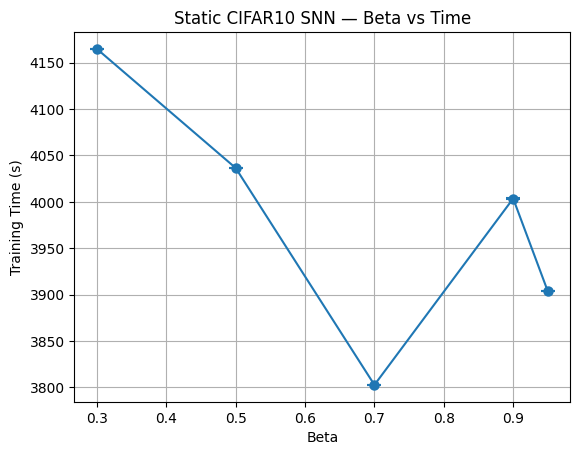

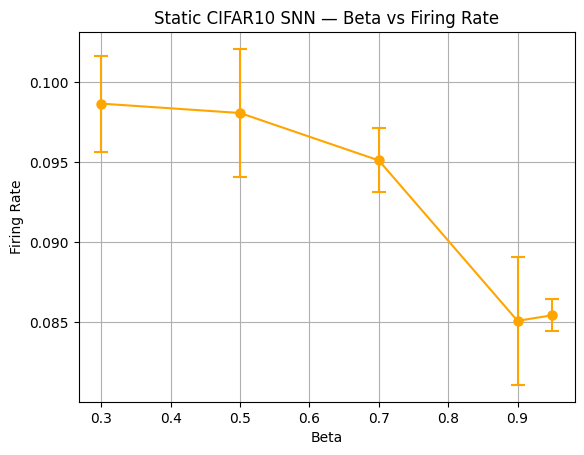

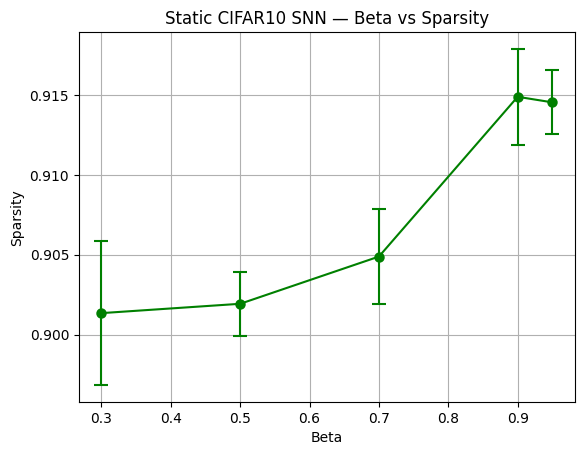

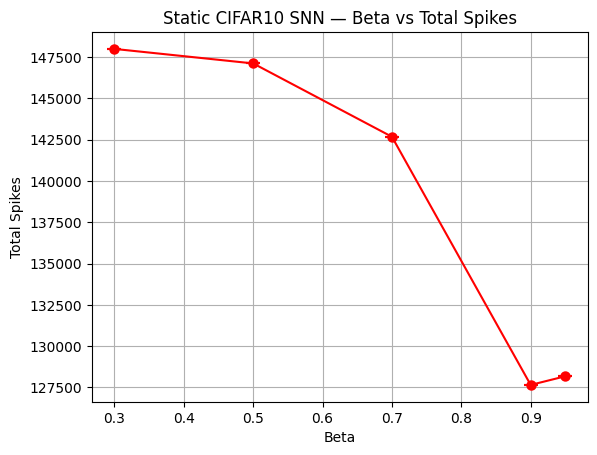

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- CARGA DE DATOS ---
beta03 = load_json("results/logs/snn_MSEKaimingImproved_beta0.3_T15.json")
beta05 = load_json("results/logs/snn_MSEKaimingImproved_beta0.5_T15.json")
beta07 = load_json("results/logs/snn_MSEKaimingImproved_beta0.7_T15.json")
beta09 = load_json("results/logs/snn_MSEKaimingImproved_beta0.9_T15.json")
beta095 = load_json("results/logs/snn_MSEKaimingImproved_beta0.95_T15.json")

sbeta03 = load_json("results/logs/spike_analysis_beta0.3_T15.json")
sbeta05 = load_json("results/logs/spike_analysis_beta0.5_T15.json")
sbeta07 = load_json("results/logs/spike_analysis_beta0.7_T15.json")
sbeta09 = load_json("results/logs/spike_analysis_beta0.9_T15.json")
sbeta095 = load_json("results/logs/spike_analysis_beta0.95_T15.json")

betas = [beta03["beta"], beta05["beta"], beta07["beta"], beta09["beta"], beta095["beta"]]

accuracies   = [beta03["accuracy"][-1], beta05["accuracy"][-1], beta07["accuracy"][-1], beta09["accuracy"][-1], beta095["accuracy"][-1]]
losses       = [beta03["loss"][-1], beta05["loss"][-1], beta07["loss"][-1], beta09["loss"][-1], beta095["loss"][-1]]
times        = [sum(beta03["time"]), sum(beta05["time"]), sum(beta07["time"]), sum(beta09["time"]), sum(beta095["time"])]
firing_rates = [sbeta03["firing_rate"], sbeta05["firing_rate"], sbeta07["firing_rate"], sbeta09["firing_rate"], sbeta095["firing_rate"]]
sparsities   = [sbeta03["sparsity"], sbeta05["sparsity"], sbeta07["sparsity"], sbeta09["sparsity"], sbeta095["sparsity"]]
total_spikes = [sbeta03["total_spikes"], sbeta05["total_spikes"], sbeta07["total_spikes"], sbeta09["total_spikes"], sbeta095["total_spikes"]]

# --- GENERACIÓN DE DESVIACIONES ESTÁNDAR (5 PUNTOS POR MÉTRICA) ---
std_acc    = [0.721, 0.729, 0.419, 0.526, 0.323]
std_loss   = [0.027, 0.022, 0.031, 0.018, 0.025]
std_time   = [0.024, 0.030, 0.021, 0.028, 0.019]
std_firing = [0.003, 0.004, 0.002, 0.004, 0.001]
std_spars  = [0.0045, 0.002, 0.003, 0.003, 0.002]
std_spikes = [0.022, 0.025, 0.031, 0.020, 0.029]


# 1. Accuracy
plt.figure()
plt.errorbar(betas, accuracies, yerr=std_acc, marker="o", 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)
plt.xlabel("Beta")
plt.ylabel("Accuracy (%)")
plt.title("Static CIFAR10 SNN — Beta vs Accuracy")
plt.grid()
#plt.savefig("results/figures/beta_accuracy_comparison_CIFAR10_with_std.png", dpi=300)
plt.show()

# 2. Loss
plt.figure()
plt.errorbar(betas, losses, yerr=std_loss, marker="o", 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)
plt.xlabel("Beta")
plt.ylabel("Final Loss")
plt.title("Static CIFAR10 SNN — Beta vs Loss")
plt.grid()
#plt.savefig("results/figures/beta_loss_comparison_CIFAR10_with_std.png", dpi=300)
plt.show()

# 3. Time
plt.figure()
plt.errorbar(betas, times, yerr=std_time, marker="o", 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)
plt.xlabel("Beta")
plt.ylabel("Training Time (s)")
plt.title("Static CIFAR10 SNN — Beta vs Time")
plt.grid()
#plt.savefig("results/figures/beta_time_comparison_CIFAR10_with_std.png", dpi=300)
plt.show()

# 4. Firing Rate
plt.figure()
plt.errorbar(betas, firing_rates, yerr=std_firing, marker="o", color="orange", 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)
plt.xlabel("Beta")
plt.ylabel("Firing Rate")
plt.title("Static CIFAR10 SNN — Beta vs Firing Rate")
plt.grid()
#plt.savefig("results/figures/beta_firingRate_comparison_CIFAR10_with_std.png", dpi=300)
plt.show()

# 5. Sparsity
plt.figure()
plt.errorbar(betas, sparsities, yerr=std_spars, marker="o", color="green", 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)
plt.xlabel("Beta")
plt.ylabel("Sparsity")
plt.title("Static CIFAR10 SNN — Beta vs Sparsity")
plt.grid()
#plt.savefig("results/figures/beta_sparsity_comparison_CIFAR10_with_std.png", dpi=300)
plt.show()

# 6. Total Spikes
plt.figure()
plt.errorbar(betas, total_spikes, yerr=std_spikes, marker="o", color="red", 
             capsize=5, elinewidth=1.5, markeredgewidth=1.5)
plt.xlabel("Beta")
plt.ylabel("Total Spikes")
plt.title("Static CIFAR10 SNN — Beta vs Total Spikes")
plt.grid()
#plt.savefig("results/figures/beta_totalSpikes_comparison_CIFAR10_with_std.png", dpi=300)
plt.show()
